In [6]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

In [13]:
# Features: [size, bedrooms]
X = np.array([
    [50, 1],
    [80, 2],
    [120, 3],
    [150, 4]
])

# Target: price
y = np.array([100000, 150000, 220000, 300000])

In [14]:
# Create model
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
new_house = [100, 2] #Size = 100 m² and Bedrooms = 2
prediction = model.predict([new_house])
print(prediction)

#Build the Formula
  #Linear Regression formula:  price=w1 x size + w2 x bedrooms + b (price= 500 x size + 50000 x bedrooms + 17500)

[167500.]


Check Model Parameters

In [21]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

#Meaning:
 # +1 m² → +$500
 # +1 bedroom → +$50000

Coefficients: [  500. 50000.]
Intercept: 17500.0


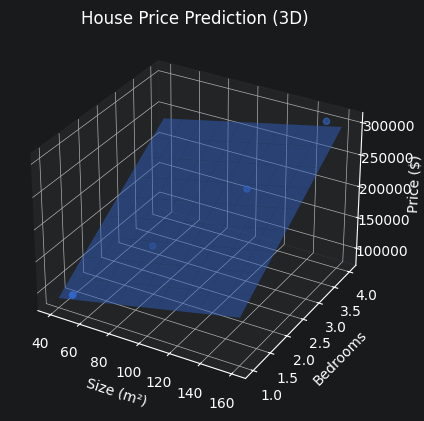

In [9]:
# Create 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Scatter actual data
ax.scatter(X[:, 0], X[:, 1], y)

# Create grid for plane
size_range = np.linspace(40, 160, 10)
bedroom_range = np.linspace(1, 4, 10)
size_grid, bedroom_grid = np.meshgrid(size_range, bedroom_range)

# Predict for grid
price_grid = model.predict(
    np.c_[size_grid.ravel(), bedroom_grid.ravel()]
).reshape(size_grid.shape)

# Plot regression plane
ax.plot_surface(size_grid, bedroom_grid, price_grid, alpha=0.5)

# Labels
ax.set_xlabel("Size (m²)")
ax.set_ylabel("Bedrooms")
ax.set_zlabel("Price ($)")
ax.set_title("House Price Prediction (3D)")

plt.show()